# Визуализация тестирования `blocksnet-mcp`

Этот блокнот показывает процесс проверки локального MCP MVP: unit/contract tests, прямые agent runs, MCP stdio smoke и артефакты из `outputs/run_*`.

По умолчанию блокнот **не запускает долгие LLM/MCP-вызовы**. Он читает уже созданные run logs и визуализирует результаты. Для повторного smoke-запуска есть отдельная опциональная ячейка.

In [1]:
# Базовая настройка ноутбука: импорты, поиск корня проекта и путей к окружению/outputs.
# Ячейка только подготавливает переменные, внешние команды и LLM-вызовы здесь не запускаются.
from __future__ import annotations

import json
import subprocess
import re
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'blocksnet_mcp').exists():
    ROOT = Path.cwd().parent

PYTHON = ROOT / '.venv' / 'Scripts' / 'python.exe'
OUTPUTS = ROOT / 'outputs'
REPORT = ROOT / 'docs' / 'reports' / 'test_report_20260618.md'

print('ROOT:', ROOT)
print('PYTHON:', PYTHON)
print('OUTPUTS exists:', OUTPUTS.exists())

ROOT: P:\AI_asistent\ITMO\blocksnet-mcp
PYTHON: P:\AI_asistent\ITMO\blocksnet-mcp\.venv\Scripts\python.exe
OUTPUTS exists: True


## 1. Карта уровней тестирования

In [2]:
# Ручная карта уровней из test_plan.md.
# Она нужна как компактная легенда: что проверено автоматически, а что остается ручным GUI-шагом.
levels = pd.DataFrame([
    {'level': '0', 'name': 'Unit/contract без LLM', 'status': 'pass', 'evidence': 'pytest: 7 passed'},
    {'level': '1', 'name': 'Прямой вызов analyze_urban_question', 'status': 'pass', 'evidence': 'run_20260618-140741-90e191'},
    {'level': '2', 'name': 'MCP stdio smoke', 'status': 'pass', 'evidence': 'run_20260618-142902-cf2759'},
    {'level': '3', 'name': 'GUI/Claude Desktop', 'status': 'not run', 'evidence': 'не запускалось из этой сессии'},
])
display(levels)

,level,name,status,evidence
0,0,Unit/contract без LLM,pass,pytest: 7 passed
1,1,Прямой вызов analyze_urban_question,pass,run_20260618-140741-90e191
2,2,MCP stdio smoke,pass,run_20260618-142902-cf2759
3,3,GUI/Claude Desktop,not run,не запускалось из этой сессии


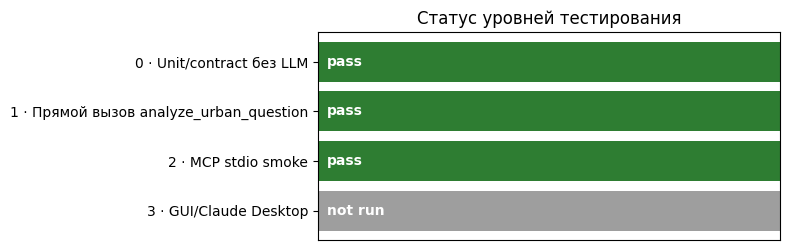

In [3]:
# Простая визуальная шкала статусов: зеленый — пройдено, серый — не запускалось, красный — ошибка.
status_colors = {'pass': '#2e7d32', 'not run': '#9e9e9e', 'fail': '#c62828'}
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.barh(levels['level'] + ' · ' + levels['name'], [1] * len(levels), color=[status_colors[s] for s in levels['status']])
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title('Статус уровней тестирования')
for i, row in levels.iterrows():
    ax.text(0.02, i, row['status'], va='center', ha='left', color='white', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2. Live pytest

Эти ячейки запускают актуальный набор unit/contract tests прямо из блокнота и строят компактную визуализацию результата.


......................                                                   [100%]
22 passed in 3.53s


,status,count
0,passed,22
1,failed,0
2,errors,0
3,skipped,0


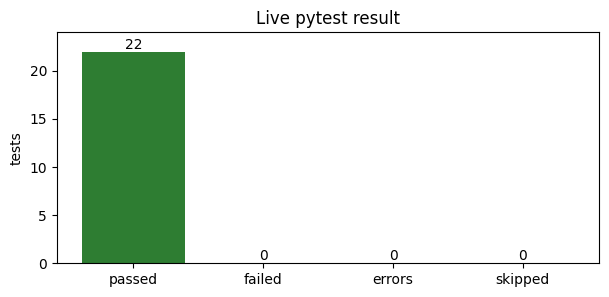

In [4]:
# Live-запуск pytest из блокнота.
# RUN_PYTEST можно переключить в False, если нужен только просмотр уже сохраненных run logs.
RUN_PYTEST = True

pytest_cmd = [str(PYTHON), '-m', 'pytest', 'tests', '-q']
if RUN_PYTEST:
    completed = subprocess.run(
        pytest_cmd,
        cwd=ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=120,
    )
    pytest_output = completed.stdout.strip()
    print(pytest_output)

    # Парсим короткую строку pytest вроде: "19 passed in 3.36s".
    passed = int(re.search(r'(\d+) passed', pytest_output).group(1)) if re.search(r'(\d+) passed', pytest_output) else 0
    failed = int(re.search(r'(\d+) failed', pytest_output).group(1)) if re.search(r'(\d+) failed', pytest_output) else 0
    errors = int(re.search(r'(\d+) error', pytest_output).group(1)) if re.search(r'(\d+) error', pytest_output) else 0
    skipped = int(re.search(r'(\d+) skipped', pytest_output).group(1)) if re.search(r'(\d+) skipped', pytest_output) else 0
    pytest_df = pd.DataFrame([
        {'status': 'passed', 'count': passed},
        {'status': 'failed', 'count': failed},
        {'status': 'errors', 'count': errors},
        {'status': 'skipped', 'count': skipped},
    ])
    display(pytest_df)

    # Цветовая схема намеренно простая: зеленый для pass, красный для проблем, серый для skipped.
    colors = ['#2e7d32', '#c62828', '#ef6c00', '#757575']
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(pytest_df['status'], pytest_df['count'], color=colors)
    ax.set_title('Live pytest result')
    ax.set_ylabel('tests')
    ax.bar_label(ax.containers[0])
    ax.set_ylim(0, max(1, pytest_df['count'].max()) + 2)
    plt.show()
else:
    display(Markdown('Live pytest выключен (`RUN_PYTEST = False`).'))


## 3. Service Routing Regression

This live check visualizes the current service routing fix: user-facing `sports` must resolve to canonical `pitch`, and scenario validation must not report unrelated services.


In [5]:
# Lightweight live regression for service routing.
# It uses internal routing helpers without running the expensive BlocksNet provision calculation.
from blocksnet.enums import LandUse
from blocksnet_agent.tools.optimize import _available_service_weights, _normalize_addition_services

synthetic_blocks = pd.DataFrame({
    'population': [100, 200],
    'capacity_pitch': [1, 2],
    'capacity_convenience': [1, 2],
    'capacity_school': [1, 2],
})
scenario_input = {0: {'sports': 10, 'convenience': 5}}
requested_weights = _available_service_weights('sports', synthetic_blocks, LandUse.RESIDENTIAL, ROOT / 'data')
normalized_scenario = _normalize_addition_services(scenario_input, synthetic_blocks, ROOT / 'data')
scenario_services = sorted({service for service_map in normalized_scenario.values() for service in service_map})
checked_services = [service for service in scenario_services if service in requested_weights]
excluded_services = [service for service in scenario_services if service not in requested_weights]

routing_rows = [
    {'check': 'service_set alias', 'input': 'sports', 'checked_service': ', '.join(requested_weights), 'excluded': '', 'expected': 'pitch', 'status': 'pass' if list(requested_weights) == ['pitch'] else 'fail'},
    {'check': 'scenario validation target', 'input': 'service_set=sports', 'checked_service': ', '.join(checked_services), 'excluded': ', '.join(excluded_services), 'expected': 'only pitch is checked', 'status': 'pass' if checked_services == ['pitch'] and excluded_services == ['convenience'] else 'fail'},
]
routing_df = pd.DataFrame(routing_rows)
display(routing_df)

counts = pd.Series({'checked target': len(checked_services), 'excluded unrelated': len(excluded_services)})
ax = counts.plot.bar(figsize=(6, 3), color=['#2e7d32', '#757575'])
ax.set_title('Scenario service filter')
ax.set_ylabel('services')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


,check,input,checked_service,excluded,expected,status
0,service_set alias,sports,pitch,,pitch,pass
1,scenario validation target,service_set=sports,pitch,convenience,only pitch is checked,pass


C:\Users\Eynor\AppData\Local\Temp\ipykernel_28580\3233111921.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 2. Загрузка run logs

In [6]:
# Read outputs/run_*/run_log.json.
# By default the notebook shows only the latest run, so historical logs with fixed bugs
# do not pollute the current validation view. Set INCLUDE_LEGACY_RUNS=True to audit history.
def load_run_log(run_dir: Path) -> dict:
    path = run_dir / 'run_log.json'
    if not path.exists():
        return {'run_id': run_dir.name.removeprefix('run_'), 'run_dir': str(run_dir), 'missing_log': True}
    data = json.loads(path.read_text(encoding='utf-8'))
    data['run_dir'] = str(run_dir)
    data['_mtime'] = run_dir.stat().st_mtime
    return data

INCLUDE_LEGACY_RUNS = False
all_run_dirs = sorted(OUTPUTS.glob('run_*')) if OUTPUTS.exists() else []
all_runs = [load_run_log(path) for path in all_run_dirs]
latest_run = max(all_runs, key=lambda item: item.get('_mtime', 0), default=None)
runs = all_runs if INCLUDE_LEGACY_RUNS else ([latest_run] if latest_run else [])

summary_rows = []
for run in runs:
    started = run.get('started_at')
    finished = run.get('finished_at')
    duration_s = None
    if started and finished:
        duration_s = (datetime.fromisoformat(finished) - datetime.fromisoformat(started)).total_seconds()
    summary_rows.append({
        'run_id': run.get('run_id'),
        'question': run.get('question', ''),
        'confidence': run.get('confidence'),
        'duration_s': duration_s,
        'tool_calls': len(run.get('tool_calls', [])),
        'saved_files': len(run.get('saved_files', [])),
        'run_dir': run.get('run_dir'),
    })

runs_df = pd.DataFrame(summary_rows)
display(Markdown(f'Using {len(runs)} current run(s); legacy runs hidden: `{not INCLUDE_LEGACY_RUNS}`.'))
display(runs_df if not runs_df.empty else Markdown('_No run logs found._'))


Using 1 current run(s); legacy runs hidden: `True`.

,run_id,question,confidence,duration_s,tool_calls,saved_files,run_dir
0,20260618-151424-01760d,Где разместить новые спортивные площадки?,0.45,44.0,8,7,P:\AI_asistent\ITMO\blocksnet-mcp\outputs\run_...


In [7]:
# Быстрые графики по всем найденным run: доверие, число tool calls и количество сохраненных файлов.
# Это помогает увидеть, какие прогоны были smoke-тестами, а какие содержательными агентскими запусками.
if not runs_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
    runs_df.plot.bar(x='run_id', y='confidence', ax=axes[0], legend=False, color='#1565c0')
    axes[0].set_title('Confidence')
    axes[0].set_ylim(0, 1)
    runs_df.plot.bar(x='run_id', y='tool_calls', ax=axes[1], legend=False, color='#6a1b9a')
    axes[1].set_title('Tool calls')
    runs_df.plot.bar(x='run_id', y='saved_files', ax=axes[2], legend=False, color='#ef6c00')
    axes[2].set_title('Saved artifacts')
    for ax in axes:
        ax.tick_params(axis='x', rotation=75)
        ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

C:\Users\Eynor\AppData\Local\Temp\ipykernel_28580\3565476680.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 3. Проверка JSON-контракта через сериализатор

In [8]:
# Повторно прогоняем сохраненные run logs через тот же сериализатор, что использует MCP tool.
# Так проверяется не только наличие run_log.json, но и соответствие итогового JSON контракту.
from blocksnet_mcp.serialize import to_json

contract_rows = []
required = ['question', 'analysis_plan', 'result', 'hypotheses', 'measured', 'recommendation_blocks', 'confidence', 'limitations', 'artifacts', 'run_id']

for run in runs:
    agent_result = {
        'input': run.get('question', ''),
        'output': run.get('final_answer', ''),
        'confidence': run.get('confidence'),
        'limitations': run.get('limitations', []),
        'run_dir': run.get('run_dir', ''),
    }
    payload = to_json(agent_result)
    contract_rows.append({
        'run_id': payload['run_id'],
        'has_all_keys': all(key in payload for key in required),
        'hypotheses': len(payload['hypotheses']),
        'measured_services': ', '.join(payload['measured'].keys()),
        'recommendation_blocks': payload['recommendation_blocks'],
        'artifacts': len(payload['artifacts']),
    })

contract_df = pd.DataFrame(contract_rows)
display(contract_df)

,run_id,has_all_keys,hypotheses,measured_services,recommendation_blocks,artifacts
0,20260618-151424-01760d,True,4,,[],7


## 4. Детализация выбранного run

In [9]:
# Detailed run selection.
# RUN_ID=None means latest/current run from the filtered run list above.
RUN_ID = None

if RUN_ID:
    selected = next((run for run in runs if run.get('run_id') == RUN_ID), runs[-1] if runs else {})
else:
    selected = runs[-1] if runs else {}
display(Markdown(f"### Run `{selected.get('run_id', '')}`"))
display(pd.DataFrame([{
    'question': selected.get('question', ''),
    'confidence': selected.get('confidence'),
    'tool_calls': len(selected.get('tool_calls', [])),
    'saved_files': len(selected.get('saved_files', [])),
}]))


### Run `20260618-151424-01760d`

,question,confidence,tool_calls,saved_files
0,Где разместить новые спортивные площадки?,0.45,8,7


In [10]:
# Смотрим последовательность инструментов и частоту вызовов.
# Это удобно для диагностики: видно, где агент повторялся, ошибался в имени сервиса или уходил в тяжелые tools.
tool_df = pd.DataFrame(selected.get('tool_calls', []))
if not tool_df.empty:
    display(tool_df[['tool', 'args']].head(30))
    counts = tool_df['tool'].value_counts().sort_values()
    ax = counts.plot.barh(figsize=(8, max(2.5, 0.35 * len(counts))), color='#455a64')
    ax.set_title('Tool call frequency')
    ax.set_xlabel('calls')
    plt.tight_layout()
    plt.show()

,tool,args
0,compute_mean_accessibility,{}
1,compute_services_density,{}
2,compute_services_centrality,{}
3,compute_services_collocation,{}
4,suggest_target_blocks,"{'criterion': 'low_provision', 'service_type':..."
5,suggest_target_blocks,"{'criterion': 'low_density', 'service_type': '..."
6,suggest_target_blocks,"{'criterion': 'low_centrality', 'service_type'..."
7,suggest_target_blocks,"{'criterion': 'low_collocation', 'service_type..."


C:\Users\Eynor\AppData\Local\Temp\ipykernel_28580\1486747383.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Eynor\AppData\Local\Temp\ipykernel_28580\1486747383.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. Артефакты и карты

In [11]:
# Таблица сохраненных артефактов: CSV, PNG-карты и служебные файлы, записанные инструментами агента.
files_df = pd.DataFrame(selected.get('saved_files', []))
if not files_df.empty:
    files_df['name'] = files_df['path'].map(lambda value: Path(value).name)
    display(files_df[['name', 'kind', 'size', 'mime']])
else:
    display(Markdown('_Нет сохраненных артефактов._'))

,name,kind,size,mime
0,mean_accessibility.csv,csv,20990,application/vnd.ms-excel
1,mean_accessibility.png,map,120535,image/png
2,services_density.csv,csv,139719,application/vnd.ms-excel
3,services_density.png,map,110885,image/png
4,services_centrality.png,map,123290,image/png
5,services_centrality.csv,csv,61421,application/vnd.ms-excel
6,services_collocation.csv,csv,37289,application/vnd.ms-excel


**mean_accessibility.png**

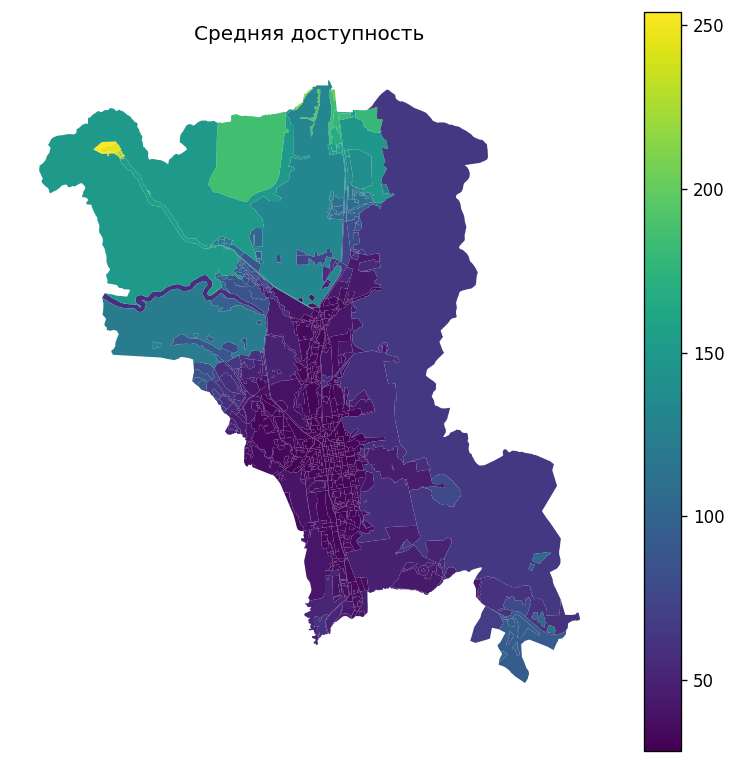

**services_density.png**

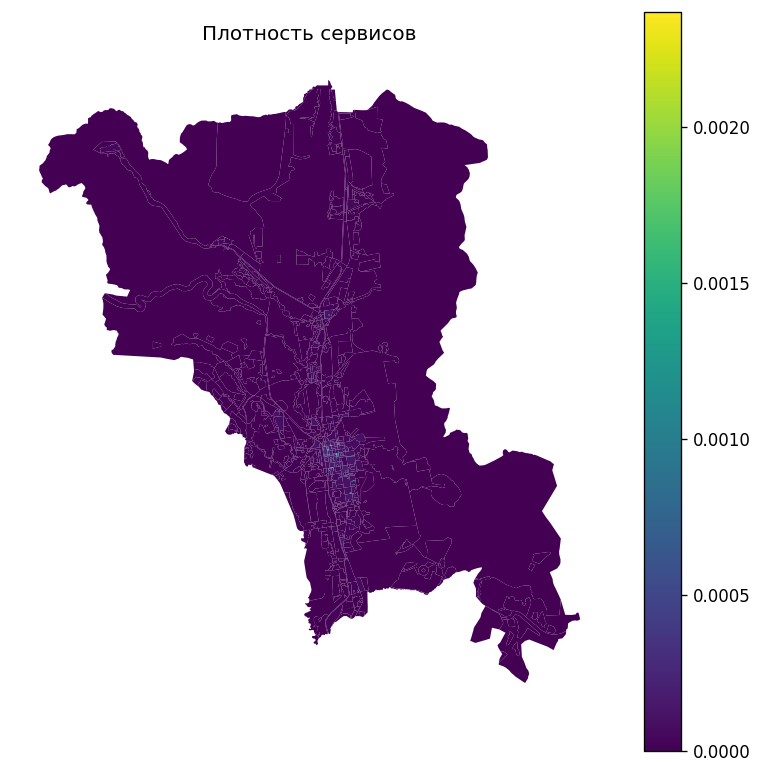

**services_centrality.png**

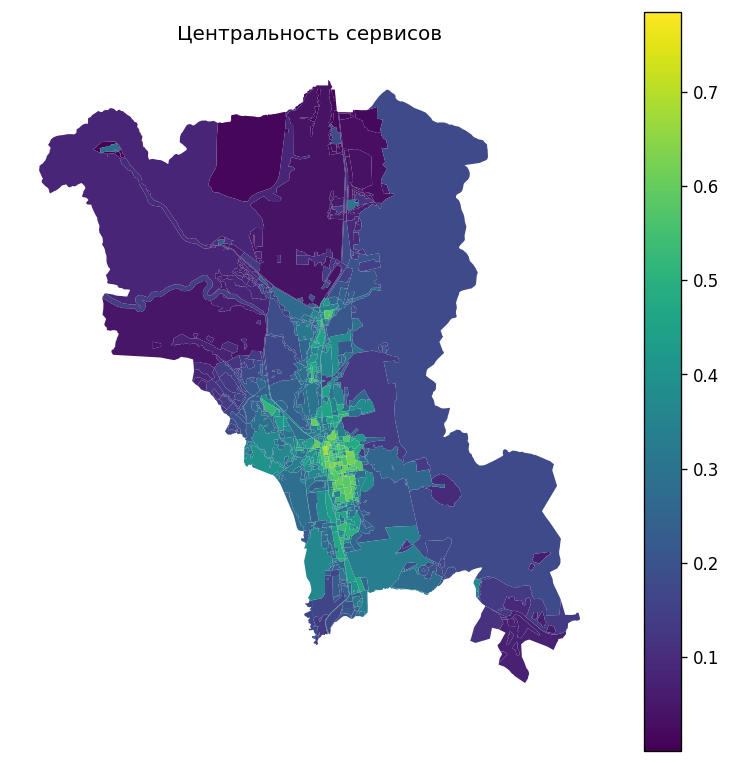

In [12]:
# Отображаем первые PNG-карты из выбранного run.
# Файлы лежат в outputs/run_*/maps и не коммитятся, поэтому блокнот рассчитан на локальную рабочую машину.
map_paths = [Path(item['path']) for item in selected.get('saved_files', []) if item.get('kind') == 'map']
for path in map_paths[:8]:
    if path.exists():
        display(Markdown(f"**{path.name}**"))
        display(Image(filename=str(path), width=640))

## 6. Опциональный повтор smoke-команд

Эта ячейка выключена по умолчанию. Включай `RUN_COMMANDS = True`, если нужно повторить проверки из ноутбука. Valid MCP call может занять несколько минут и использует внешний LLM.

In [13]:
# Опциональный live-запуск проверок из ноутбука.
# По умолчанию выключено, чтобы случайно не дернуть внешний LLM и не ждать долгий MCP call.
RUN_COMMANDS = False

commands = [
    [str(PYTHON), '-m', 'pip', 'check'],
    [str(PYTHON), '-m', 'pytest', 'tests', '-q'],
    [str(PYTHON), 'scripts/smoke_client.py'],
    # Долгий вызов, включать осознанно:
    # [str(PYTHON), 'scripts/smoke_client.py', '--call', '--max-iterations', '1', '--call-timeout', '180'],
]

if RUN_COMMANDS:
    for command in commands:
        print('> ' + ' '.join(command))
        result = subprocess.run(command, cwd=ROOT, text=True, capture_output=True, timeout=240)
        print(result.stdout)
        if result.stderr:
            print(result.stderr)
        print('returncode:', result.returncode)
else:
    print('RUN_COMMANDS=False; команды не запускались.')

RUN_COMMANDS=False; команды не запускались.


## 7. Статический отчет

Сводный Markdown-отчет лежит в [`docs/reports/test_report_20260618.md`](../docs/reports/test_report_20260618.md).

In [14]:
# Показываем начало статического Markdown-отчета прямо в ноутбуке.
# Полную версию удобнее читать в docs/reports/test_report_20260618.md.
if REPORT.exists():
    text = REPORT.read_text(encoding='utf-8')
    display(Markdown('\n'.join(text.splitlines()[:40]) + '\n\n...'))
else:
    print('Report not found:', REPORT)

# Отчет о тестировании `blocksnet-mcp`

Дата: 2026-06-18  
Объем: локальный MCP MVP, транспорт `stdio`, локальные данные `data/`, внешний OpenAI-compatible LLM.  
План: [`docs/plans/test_plan.md`](../plans/test_plan.md) *(локальный рабочий план, gitignored)*.

## Резюме

Локальный MVP проверен по уровням 0-2. Контрактная логика, прямой вызов агента и MCP stdio-транспорт
работают. GUI-проверка в Claude Desktop / целевом MCP-клиенте не выполнялась из этой сессии.

| Уровень | Проверка | Статус | Итог |
|---|---|---:|---|
| 0 | Unit/contract без LLM | ✅ | `22 passed` |
| 1 | Прямой вызов `analyze_urban_question` | ✅ | JSON-контракт, run logs и артефакты созданы |
| 2 | MCP stdio через `scripts/smoke_client.py` | ✅ | `list_tools`, invalid call и valid call проверены |
| 3 | Реальный GUI-клиент | ⏭️ | Не запускалось; конфиг готов |

## Окружение

| Компонент | Значение |
|---|---|
| Python | `3.10.11` |
| Интерпретатор | `.\.venv\Scripts\python.exe` |
| Зависимости | `requirements.txt` |
| LLM | `openai/gpt-4o` через OpenRouter-compatible endpoint |
| Данные | `data/blocks_with_services.gpkg`, `data/acc_mx.pickle`, `data/service_type.json`, `data/archetypes.csv` |
| MCP entrypoint | `.\.venv\Scripts\python.exe -m blocksnet_mcp.server` |

Проверка зависимостей:

```text
.\.venv\Scripts\python.exe -m pip check
No broken requirements found.
```

## Уровень 0

Команда:


...